# **SPECTRA v2**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import torch
import json
import networkx as nx
from matplotlib import pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
from torch_geometric.utils import from_networkx
import os
from tqdm import tqdm
from scipy import sparse
import anndata as ad

import warnings
warnings.filterwarnings("ignore")

/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


In [3]:
# torch device setting
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(torch.version.cuda)
    print(torch.cuda.get_device_name())
else:
    device = torch.device('cpu')
print(device)

12.1
Tesla V100-SXM2-32GB
cuda


In [4]:
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/michele.calabro/.netrc.
wandb: Currently logged in as: michi-geco97 (michi-geco97-politecn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

### **Data import**

In [5]:
# data loading and filtering
adata = sc.read_h5ad('../data/vcc_data/adata_Training.h5ad') #VCC
#adata = sc.read_h5ad('../data/replogle_k562_essential/perturb_processed.h5ad') # replogle
adata

AnnData object with n_obs × n_vars = 221273 × 18080
    obs: 'target_gene', 'guide_id', 'batch'
    var: 'gene_id'

***

**NOTE**: the following is JUST for Replogle dataset (rename columns)

In [ ]:
# Rename column and ctrl samples
adata.obs = adata.obs.rename(columns={"condition": "target_gene"})
adata.obs["target_gene"] = adata.obs["target_gene"].str.replace("ctrl", "non-targeting", regex=False)

# rename of single perturbations
adata.obs["target_gene"] = adata.obs["target_gene"].str.replace("ctrl", "non-targeting", regex=False)
adata.obs['target_gene'] = adata.obs['target_gene'].str.replace(r'\+non-targeting$', '', regex=True)

adata

AnnData object with n_obs × n_vars = 162751 × 5000
    obs: 'target_gene', 'cell_type', 'cov_drug_dose_name', 'dose_val', 'control', 'condition_name'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'

***

**filtering and normalization**: quite standard, we remove perturbations with less than 100 samples (can be changed)

In [6]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3) # TODO: should be 3 but if so I would have to recalculate the GRN....
adata

AnnData object with n_obs × n_vars = 221273 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'

In [7]:
adata.raw = adata.copy() 
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)

# select only perturbations that are present in at least 200 cells
counts = adata.obs['target_gene'].value_counts()
valid_pert = counts[counts >= 100].index
adata = adata[adata.obs['target_gene'].isin(valid_pert)]
del counts
del valid_pert
adata

View of AnnData object with n_obs × n_vars = 220998 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

### **GRN preparation**

***
### Patrick stuff

In [8]:
# patrick guanlab (stock)
A = np.load('Patrick_networks/guanlab_stock_3.5k_directed.npz')
adjacency = A['adjacency']
gene_names = A['gene_names']

# Create weighted DiGraph (parallel_edges=False treats values as weights)
G = nx.from_numpy_array(
    adjacency,
    parallel_edges=False,
    create_using=nx.DiGraph(),
    edge_attr='weight',  # Attribute name for weights
)

# Relabel nodes with gene names (must be same length as matrix dims)
mapping = {i: gene_names[i] for i in range(len(gene_names))}
G = nx.relabel_nodes(G, mapping)

# naive pruning
G.remove_edges_from([(u, v) for u, v, d in G.edges(data=True) if np.log(d['weight']+1) < 8])

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1
print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

# filter adata
gene_list = gene_names.tolist()
mask = adata.var_names.isin(gene_names)
adata = adata[:, mask].copy()
adata

Number of nodes: 3406
Number of edges: 474761
Number of node features per node: 1


AnnData object with n_obs × n_vars = 220998 × 3406
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

### End of patrick stuff
***

### Replogle SCENIC grn

In [ ]:
# network file
with open('../SCENIC_GRNs/SCENIC_GRNs/networks/repogle_network.json', 'r') as json_file:
    network = json.load(json_file)
    
# Create the networkx graph
G = nx.DiGraph()
for tf, targets in network.items():
    for target, weight in targets:
        G.add_edge(tf, target, weight=weight)

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1
gene_list = list(G.nodes)

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

# filtering data to gene contained in the network G
adata.var_names = adata.var['gene_name'].astype(str)
adata.var_names_make_unique()
adata = adata[:, adata.var_names.isin(gene_list)]

# perturbation filtering
perturbations = list(adata.obs['target_gene'].unique())
perturbations.remove('non-targeting')
perts_not_included = [pert for pert in perturbations if not pert in gene_list]
adata = adata[~adata.obs['target_gene'].isin(perts_not_included)].copy()

# adata rows shuffle (otherwise perturbations are all ordered)
adata = adata[np.random.permutation(adata.n_obs), :].copy()
adata

Number of nodes: 3390
Number of edges: 11995
Number of node features per node: 1


AnnData object with n_obs × n_vars = 52525 × 3390
    obs: 'target_gene', 'cell_type', 'cov_drug_dose_name', 'dose_val', 'control', 'condition_name'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'

***

### GRNBoost2 VCC network on 3406 genes

In [ ]:
# load GRN
network_data = pd.read_csv('../SCENIC_GRNs/SCENIC_GRNs/temp_results/adjacencies_vcc_3406.tsv', sep='\t')

# Create the networkx graph
G = nx.DiGraph()
for i in range(network_data.shape[0]):
    edge = network_data.iloc[i,:]
    if np.abs(edge['importance'])>0.0: #TODO: dumb pruning, make somehting better please
        G.add_edge(edge['TF'], edge['target'], weight=edge['importance'])

gene_list = list(G.nodes)

mask = adata.var_names.isin(gene_list)
adata = adata[:, mask].copy()
adata

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)

Number of nodes: 3391
Number of edges: 213388


***

**Once loaded the network file**, check compatibility with the dataset variables and relabel the nodes

In [9]:
# check if the node names of th enwtrokx graph aorresponds to adata.var_names
assert set(G.nodes) == set(adata.var_names), "Nodes in G and adata.var_names differ!"

In [10]:
# relabel networkx node indices to match the adata
gene_to_idx = {node: i for i, node in enumerate(adata.var_names)}
G = nx.relabel_nodes(G, gene_to_idx)
edge_index = from_networkx(G, group_edge_attrs='all').edge_index # this way, edge_index follows the gene order of adata.var_names

Hyperparameters and wandb setup:

In [11]:
# here we put all the hyperparameters, metadata and stuff
config = dict(
    dataset_size=adata.shape[0],#(adata.obs['target_gene'] != 'non-targeting').sum(),
    test_ratio=0.2,
    val_ratio=0.1,
    batch_size=48,
    n_channels=24,
    edge_dropout_p=0.0,
    lr=0.001,
    n_epochs=20,
    dataset="VCC",
    architecture="DirGCNConv(MixHop)")

In [12]:
# Initialize wandb run
wandb.init(
    project="spectra-v2",       # The name of your project in wandb
    name="MixHop_firstTest",   # (Optional) Name of this specific run
    config=config               # Pass your dictionary here!
)

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


### **Dataloaders preparation**
Compared with the original SPECTRA model, here we should calculate the dataloaders so that in each batch there are only samples taken from the same perturbations.

**NOTE**: currently the split is random cell-wise, if we want to esclude some perturbations, I think it's enough to sort the dataset by column `target_gene`

In [13]:
from utils import build_model_dataloaders

train_loader, val_loader, test_loader, train_size, test_size, _ = build_model_dataloaders(adata, edge_index, config)

Train dataset size: 127831
Test dataset size: 36701
Validation dataset size: 18290


Weights based on (gorund-truth) DEGs:

In [14]:
#NOTE: new DEGs weights
from WMSE import compute_weights

gene_weights = compute_weights(adata[0:train_size,:], gene_to_idx, cells_per_pert=256)

Calculating WMSE Weights: 100%|██████████| 145/145 [00:00<00:00, 1719.86it/s]


The following plot shows the **distribution** of weights calulated with `compute_weights`:

mean: 0.00029359947
std: 0.001851991
min: 0.0
max: 0.17829487
median: 4.959281e-05


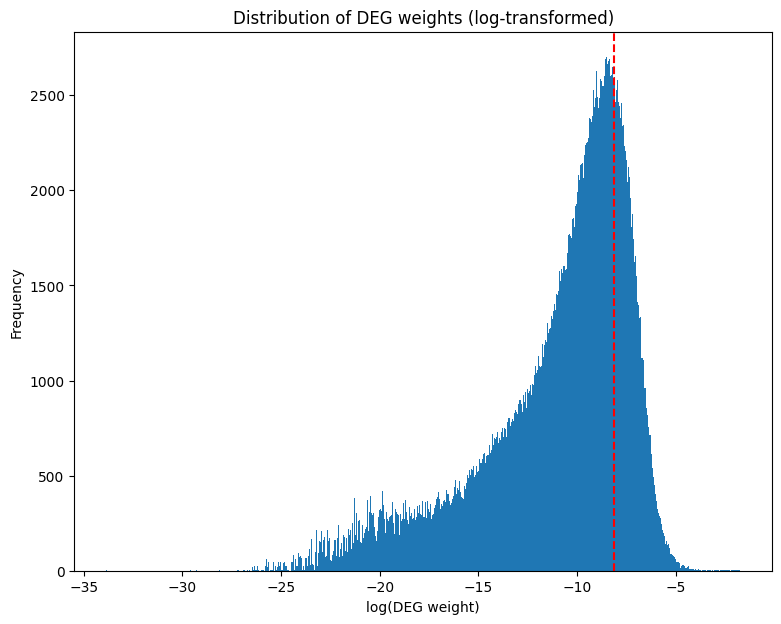

In [26]:
values = list(gene_weights.values())
perts = list(gene_weights.keys())

arr = np.array(values)

print("mean:", arr.mean())
print("std:", arr.std())
print("min:", arr.min())
print("max:", arr.max())
print("median:", np.median(arr))


uniform_weight = 1/gene_weights[1264].size
data = np.array(list(gene_weights.values()))
data = data[data > 0]

log_data = np.log(data)

plt.figure(figsize=(9,7))
plt.hist(log_data, bins=1000)
plt.xlabel('log(DEG weight)')
plt.ylabel('Frequency')
plt.title('Distribution of DEG weights (log-transformed)')
plt.axvline(np.log(uniform_weight), linestyle='--', color='red')
plt.show()


### **Model setup**

In [27]:
from spectra_v2 import PerturbModel

model = PerturbModel(
    edge_index, 
    num_nodes, 
    device, 
    gene_weights=gene_weights, 
    num_node_features=1, 
    n_channels=config['n_channels'], 
    edge_dropout_p = config['edge_dropout_p']
)
model = model.to(device)
print(model)

number of trainable parameters: 239561
PerturbModel(
  (ko_mu): Embedding(3406, 64)
  (ko_mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.2, inplace=False)
      (1): Linear(in_features=64, out_features=24, bias=True)
      (2): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU()
      (4): Dropout(p=0.2, inplace=False)
      (5): Linear(in_features=24, out_features=24, bias=True)
      (6): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (encoder): VariationalGraphEncoder(
    (conv1): DirGNNConv(ChebConv(1, 24, K=2, normalization=sym), alpha=0.5)
    (ln1): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
    (conv2): DirGNNConv(ChebConv(24, 48, K=2, normalization=sym), alpha=0.5)
    (ln2): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
    (conv_mu): DirGNNConv(ChebConv(48, 24, K=1, normalization=sym), alpha=0.5)
    (conv_logstd): DirGNNConv(ChebConv(48, 24, K=1, normal

In [ ]:
from spectra_v2 import train
_, _, test_wmse = train(model=model, 
    train_loader=train_loader, 
    test_loader=val_loader,
    lr=config['lr'], 
    n_epochs=config['n_epochs'],  
    device=device,
    wandb_support=True,
    live_plot=False)

In [ ]:
wandb.finish()

In [22]:
torch.save(model.state_dict(), "test_19_mar.pth")

***

### **Testing**

In [ ]:
model.load_state_dict(torch.load("weights/echoes_weights_epoch_12.pth"))

In [15]:
model.eval()

PerturbModel(
  (ko_mu): Embedding(3406, 64)
  (ko_mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.2, inplace=False)
      (1): Linear(in_features=64, out_features=24, bias=True)
      (2): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU()
      (4): Dropout(p=0.2, inplace=False)
      (5): Linear(in_features=24, out_features=24, bias=True)
      (6): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (encoder): VariationalGraphEncoder(
    (conv1): DirGNNConv(ChebConv(1, 24, K=3, normalization=sym), alpha=0.5)
    (ln1): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
    (conv2): DirGNNConv(ChebConv(24, 48, K=3, normalization=sym), alpha=0.5)
    (ln2): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
    (conv_mu): DirGNNConv(ChebConv(48, 24, K=2, normalization=sym), alpha=0.5)
    (conv_logstd): DirGNNConv(ChebConv(48, 24, K=2, normalization=sym), alpha=0.5)
  )
  (gex_dec

Build the test adata `real_adata`- last n rows of the entire dataset (NOTE: adjust if needed)

In [16]:
n_cells = test_size
real_adata = adata[-n_cells:, :]
n_min_samples = 100
counts = real_adata.obs['target_gene'].value_counts()
counts = counts[counts >= n_min_samples]
gene_counts_dict = counts.drop('non-targeting').to_dict() # creation of dict: for each pertuyrbation how many cells to generate
real_adata = real_adata[real_adata.obs['target_gene'].isin(counts.index)]
real_adata

View of AnnData object with n_obs × n_vars = 34704 × 3406
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

The dictionary `gene_count_dict` contains, for each perturbation, **the number of cells we want the model to generate with that perturbation**. Above, we have set the abundance of cells for each perturbation to be the same as in `real adata`.

This dictionary is the **main input** to be passed to spectra in order to generate a synthetic Perturb-seq dataset, as show in the next cell:

In [17]:
from utils import generate_adata_from_control

pred_adata = generate_adata_from_control(gene_counts_dict, real_adata, model, gene_to_idx, real_adata.var_names)
pred_adata

100%|██████████| 112/112 [06:21<00:00,  3.41s/it]


AnnData object with n_obs × n_vars = 28445 × 3406
    obs: 'target_gene'

Here, we **concatenate** to the generated, syntetic dataset `pred_adata` the **ground truth control cells**. Why? Because we need them to calculate DEGs 

In [18]:
# Append the non-targeting controls to the example anndata if they're missing
ntc_adata = real_adata[real_adata.obs["target_gene"] == "non-targeting"]
if "non-targeting" not in pred_adata.obs["target_gene"].unique():
    assert np.all(pred_adata.var_names.values == ntc_adata.var_names.values), (
        "Gene-Names are out of order or unequal"
    )
    pred_adata = ad.concat(
        [
            pred_adata,
            ntc_adata,
        ]
    )
del ntc_adata
pred_adata

AnnData object with n_obs × n_vars = 34704 × 3406
    obs: 'target_gene'

### **My Benchmark tools**

First thing first, a **baseline** is needed:
* for each perturbation *already seen* during training, we return the average gene expression of all the samples in the training data (`adata[:train_size,:]`) with that perturbation label
* for perturbations *NOT seen* suring training, we return the average of the average of gene expressions for all perturbations (very naive baseline but it's very popular in most benchmark)

In [41]:
from utils import generate_adata_baseline

pred_adata_2 = generate_adata_baseline(gene_counts_dict, adata[:train_size,:],real_adata.var_names)

# Append the non-targeting controls to the example anndata if they're missing
ntc_adata = real_adata[real_adata.obs["target_gene"] == "non-targeting"]
if "non-targeting" not in pred_adata_2.obs["target_gene"].unique():
    assert np.all(pred_adata_2.var_names.values == ntc_adata.var_names.values), (
        "Gene-Names are out of order or unequal"
    )
    pred_adata_2 = ad.concat(
        [
            pred_adata_2,
            ntc_adata,
        ]
    )
del ntc_adata
pred_adata_2

100%|██████████| 112/112 [00:00<00:00, 1490.29it/s]


AnnData object with n_obs × n_vars = 34704 × 3406
    obs: 'target_gene'

#### Old metrics:

In [19]:
from scores import MAE_error
from scores import corr_error

MAE_error(real_adata, pred_adata)

{'DLG5': np.float32(0.028553484), 'DNMT1': np.float32(0.06355789), 'PTPN1': np.float32(0.017797263), 'BIRC2': np.float32(0.028204402), 'non-targeting': np.float32(0.0), 'UQCRQ': np.float32(0.027785147), 'IGF2R': np.float32(0.017515052), 'NCK2': np.float32(0.018010166), 'TMSB10': np.float32(0.037713032), 'PRCP': np.float32(0.017921556), 'TARBP2': np.float32(0.019483313), 'INSIG1': np.float32(0.03448002), 'SAFB': np.float32(0.033492018), 'TADA1': np.float32(0.041904658), 'HIRA': np.float32(0.019734941), 'ARID1A': np.float32(0.032838468), 'TGFBR2': np.float32(0.035233866), 'HMGB2': np.float32(0.022724561), 'NISCH': np.float32(0.019788507), 'KDM2B': np.float32(0.025496379), 'DHCR24': np.float32(0.022703066), 'NDUFB4': np.float32(0.024419865), 'LAD1': np.float32(0.01854815), 'STAG2': np.float32(0.042654105), 'EIF4B': np.float32(0.029476821), 'TFAM': np.float32(0.031287637), 'ATP1B1': np.float32(0.018218411), 'TMSB4X': np.float32(0.020759132), 'SRC': np.float32(0.0187188), 'MED13': np.float3

In [22]:
from scores import corr_error

corr_error(real_adata, pred_adata)

{'DLG5': np.float32(0.99575007), 'DNMT1': np.float32(0.97308517), 'PTPN1': np.float32(0.9989334), 'BIRC2': np.float32(0.996643), 'non-targeting': np.float32(0.9999999), 'UQCRQ': np.float32(0.99657434), 'IGF2R': np.float32(0.9986241), 'NCK2': np.float32(0.9987963), 'TMSB10': np.float32(0.9869462), 'PRCP': np.float32(0.9986377), 'TARBP2': np.float32(0.99850065), 'INSIG1': np.float32(0.99332505), 'SAFB': np.float32(0.994069), 'TADA1': np.float32(0.9893826), 'HIRA': np.float32(0.99751073), 'ARID1A': np.float32(0.9937748), 'TGFBR2': np.float32(0.9940511), 'HMGB2': np.float32(0.9977871), 'NISCH': np.float32(0.99840117), 'KDM2B': np.float32(0.9972251), 'DHCR24': np.float32(0.9972755), 'NDUFB4': np.float32(0.9974506), 'LAD1': np.float32(0.9985895), 'STAG2': np.float32(0.98916245), 'EIF4B': np.float32(0.9945502), 'TFAM': np.float32(0.99400157), 'ATP1B1': np.float32(0.99869543), 'TMSB4X': np.float32(0.8781498), 'SRC': np.float32(0.9986442), 'MED13': np.float32(0.99590385), 'CDCA2': np.float32(0.

#### AUPRC score: the ultimate DEGs evaluation metric

In [ ]:
from scores import calculate_auprc_score

results_df = calculate_auprc_score(real_adata, pred_adata)

baseline_average = results_df['baseline_auprc'].mean()
model_average = results_df['model_auprc'].mean()

plt.figure(figsize=(15, 7))
bars = plt.bar(results_df['perturbation'], results_df['model_auprc'])#, color='steelblue', alpha=0.7)
plt.xticks(rotation=90, ha='right')  # Vertical labels like your plot
plt.axhline(y=baseline_average, color='red', linestyle='--', label=f'Baseline mean DES: {baseline_average:.2f}')
plt.axhline(y=model_average, color='green', linestyle='--', label=f'Model mean DES: {model_average:.2f}')
plt.ylabel('DES')
plt.title('DES score')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Here below, same score but compared with the average baseline defined before

In [ ]:
from scores import calculate_auprc_score

# Calculate scores for both models
results_df_1 = calculate_auprc_score(real_adata, pred_adata)
results_df_2 = calculate_auprc_score(real_adata, pred_adata_2)

# 2. Merge them to ensure perturbations line up perfectly
# This creates columns: model_auprc_spectra and model_auprc_baseline
merged_df = results_df_1.merge(
    results_df_2[['perturbation', 'model_auprc']], 
    on='perturbation', 
    suffixes=('_spectra', '_baseline')
)

# 3. Calculate global averages
global_theoretical_baseline = merged_df['baseline_auprc'].mean()
global_spectra_score = merged_df['model_auprc_spectra'].mean()
global_baseline_model_score = merged_df['model_auprc_baseline'].mean()

# 4. Set up the grouped bar chart coordinates
x = np.arange(len(merged_df['perturbation']))  # the label locations
width = 0.35  # the width of the bars

# 5. Plotting
plt.figure(figsize=(15, 7))

# Plot SPECTRA slightly to the left, and the Baseline slightly to the right
bars1 = plt.bar(x - width/2, merged_df['model_auprc_spectra'], width, label='SPECTRA', color='steelblue', alpha=0.8)
bars2 = plt.bar(x + width/2, merged_df['model_auprc_baseline'], width, label='Baseline Model', color='darkorange', alpha=0.8)

# Add X-axis ticks and labels
plt.xticks(x, merged_df['perturbation'], rotation=90, ha='right')

# Add horizontal lines for the global averages
plt.axhline(y=global_theoretical_baseline, color='red', linestyle='--', 
            label=f'Random Guess Avg: {global_theoretical_baseline:.2f}')
plt.axhline(y=global_spectra_score, color='steelblue', linestyle='-.', 
            label=f'SPECTRA Avg: {global_spectra_score:.2f}')
plt.axhline(y=global_baseline_model_score, color='darkorange', linestyle='-.', 
            label=f'Baseline Avg: {global_baseline_model_score:.2f}')

# Labels and formatting
plt.ylabel('AUPRC Score') # Adjusted to match the metric being calculated
plt.title('AUPRC Score Comparison by Perturbation')
plt.legend(frameon=False, loc='upper right')
plt.tight_layout()

plt.show()

This is my custom and robus F1 classification score, still useful.

In [28]:
from scores import RobustDES

des_calculator = RobustDES(lfc_threshold=0.3, alpha=0.05)

assert set(real_adata.obs['target_gene'].unique()) == set(pred_adata.obs['target_gene'].unique()), "perturbations do not match"

perts = [pert for pert in real_adata.obs['target_gene'].unique() if pert != 'non-targeting']
scores = {}
for pert in perts:
    scores[pert] = des_calculator.calculate_f1_score(real_adata, pred_adata, 'target_gene', pert, 'non-targeting')
    print(f'score: {scores[pert]}')
    print('---------------------')
global_score = sum(scores.values())/len(scores)
print(f'average score: {global_score}')

pert DLG5 - n_true = 101, n_pred = 102
score: 0.00985221174792168
---------------------
pert DNMT1 - n_true = 1063, n_pred = 101
score: 0.05154639016687633
---------------------
pert PTPN1 - n_true = 3, n_pred = 109
score: 0.0178571423325893
---------------------
pert BIRC2 - n_true = 109, n_pred = 104
score: 0.01877933772399789
---------------------
pert UQCRQ - n_true = 107, n_pred = 112
score: 0.00913241509309921
---------------------
pert IGF2R - n_true = 8, n_pred = 97
score: 0.01904761763628128
---------------------
pert NCK2 - n_true = 1, n_pred = 98
score: 0.0
---------------------
pert TMSB10 - n_true = 322, n_pred = 99
score: 0.038004746994883015
---------------------
pert PRCP - n_true = 4, n_pred = 95
score: 0.0
---------------------
pert TARBP2 - n_true = 6, n_pred = 95
score: 0.0
---------------------
pert INSIG1 - n_true = 370, n_pred = 107
score: 0.03773584557502593
---------------------
pert SAFB - n_true = 242, n_pred = 117
score: 0.03342617944832889
-----------------

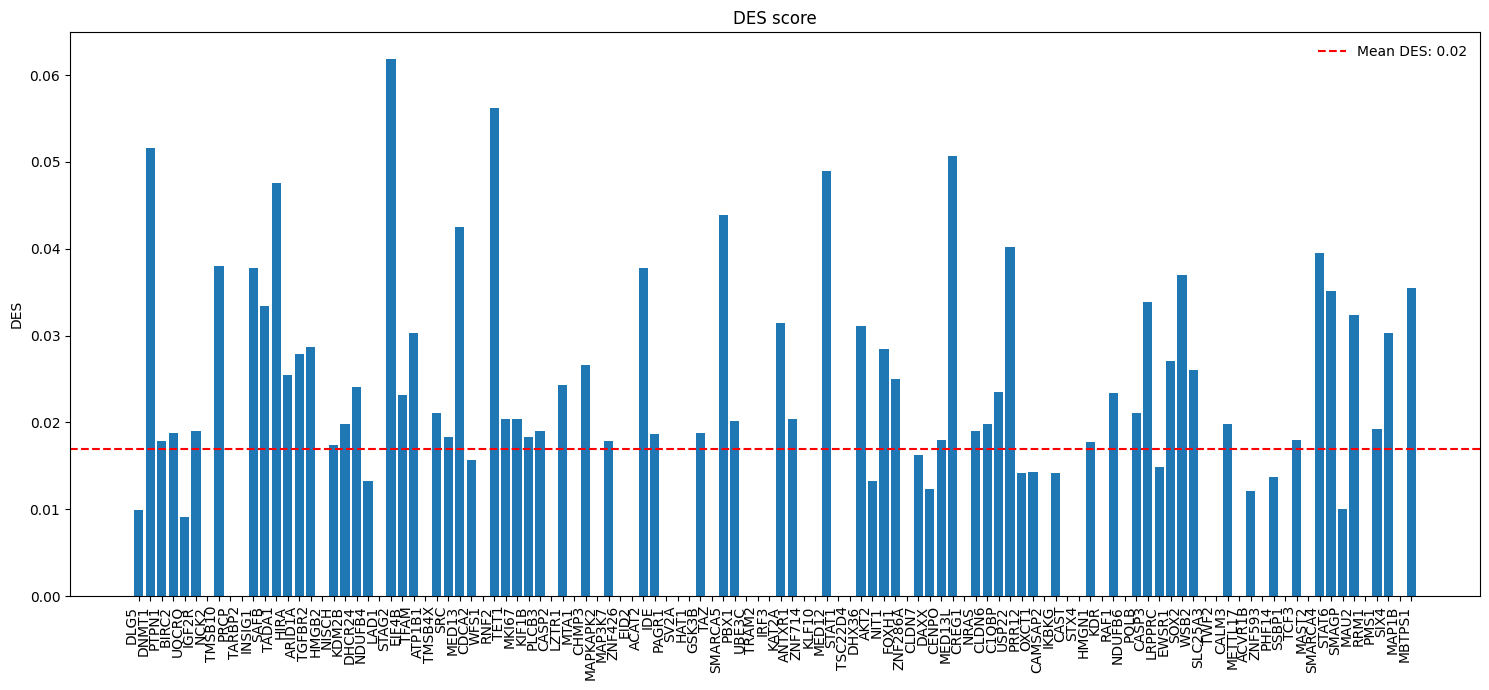

In [29]:
values = list(scores.values())

mean_score = sum(values) / len(values)  # Or use statistics.mean(values)

plt.figure(figsize=(15, 7))
bars = plt.bar(perts, values)#, color='steelblue', alpha=0.7)
plt.xticks(rotation=90, ha='right')  # Vertical labels like your plot
plt.axhline(y=mean_score, color='red', linestyle='--', label=f'Mean DES: {global_score:.2f}')
plt.ylabel('DES')
plt.title('DES score')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

100%|██████████| 104/104 [03:00<00:00,  1.73s/it]


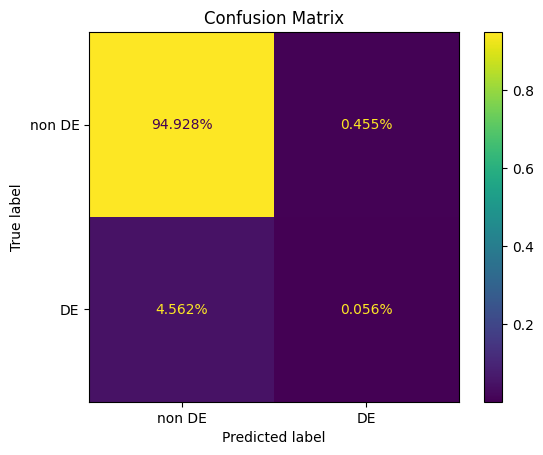

array([[9.49275035e-01, 4.54514657e-03],
       [4.56236732e-02, 5.56145264e-04]])

In [52]:
des_calculator.DES_confusion_matrix(perts,real_adata,pred_adata,'target_gene', 'non-targeting')

### Benchmark new
taken from paper [Benchmarking algorithms for generalizable single-cell perturbation response prediction](https://www.nature.com/articles/s41592-025-02980-0)

  0%|          | 0/112 [00:00<?, ?it/s]

  1%|          | 1/112 [00:01<02:48,  1.52s/it]

  2%|▏         | 2/112 [00:03<02:49,  1.54s/it]

  3%|▎         | 3/112 [00:04<02:49,  1.55s/it]

  4%|▎         | 4/112 [00:06<02:52,  1.60s/it]

...

 96%|█████████▋| 108/112 [02:52<00:06,  1.57s/it]

 97%|█████████▋| 109/112 [02:54<00:04,  1.57s/it]

 98%|█████████▊| 110/112 [02:55<00:03,  1.58s/it]

 99%|█████████▉| 111/112 [02:57<00:01,  1.59s/it]

100%|██████████| 112/112 [02:59<00:00,  1.60s/it]


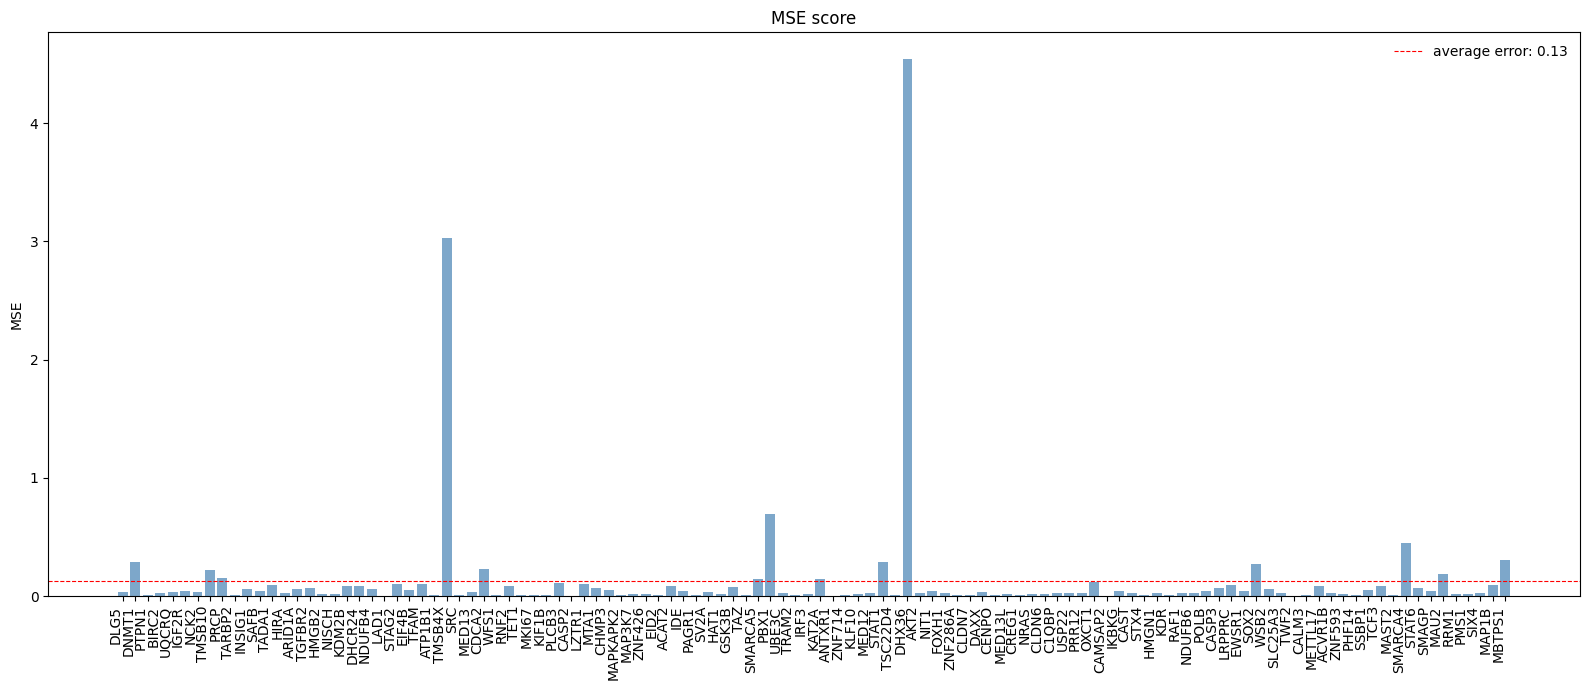

In [22]:
from benchmark import calc_mse, calc_pcc_delta, calc_edistance, calc_wasserstein, calc_kldiv, calc_common_degs
import statistics

result_mse = calc_mse(real_adata,pred_adata, n_top_degs=50)

# Extract keys and values
perts = list(result_mse.keys())
values = list(result_mse.values())

mean_score = sum(values) / len(values)
median_score = statistics.median(values)

plt.figure(figsize=(16, 7))
bars = plt.bar(perts, values, color='#4C72B0', alpha=0.9)
plt.xticks(rotation=90, ha='right')  # Vertical labels like your plot
plt.axhline(y=mean_score, color='#DD8452', linestyle='--', linewidth=0.8, label=f'average error: {mean_score:.2f}')
plt.axhline(y=mean_score, color='#55A868', linestyle='--', linewidth=0.8, label=f'average error: {median_score:.2f}')
plt.ylabel('MSE')
plt.title('MSE score')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

  0%|          | 0/112 [00:00<?, ?it/s]

  1%|          | 1/112 [00:01<02:40,  1.45s/it]

  2%|▏         | 2/112 [00:02<02:41,  1.46s/it]

  3%|▎         | 3/112 [00:04<02:47,  1.54s/it]

  4%|▎         | 4/112 [00:06<02:49,  1.57s/it]

...

 96%|█████████▋| 108/112 [02:52<00:06,  1.58s/it]

 97%|█████████▋| 109/112 [02:53<00:04,  1.59s/it]

 98%|█████████▊| 110/112 [02:55<00:03,  1.59s/it]

 99%|█████████▉| 111/112 [02:57<00:01,  1.60s/it]

100%|██████████| 112/112 [02:58<00:00,  1.60s/it]


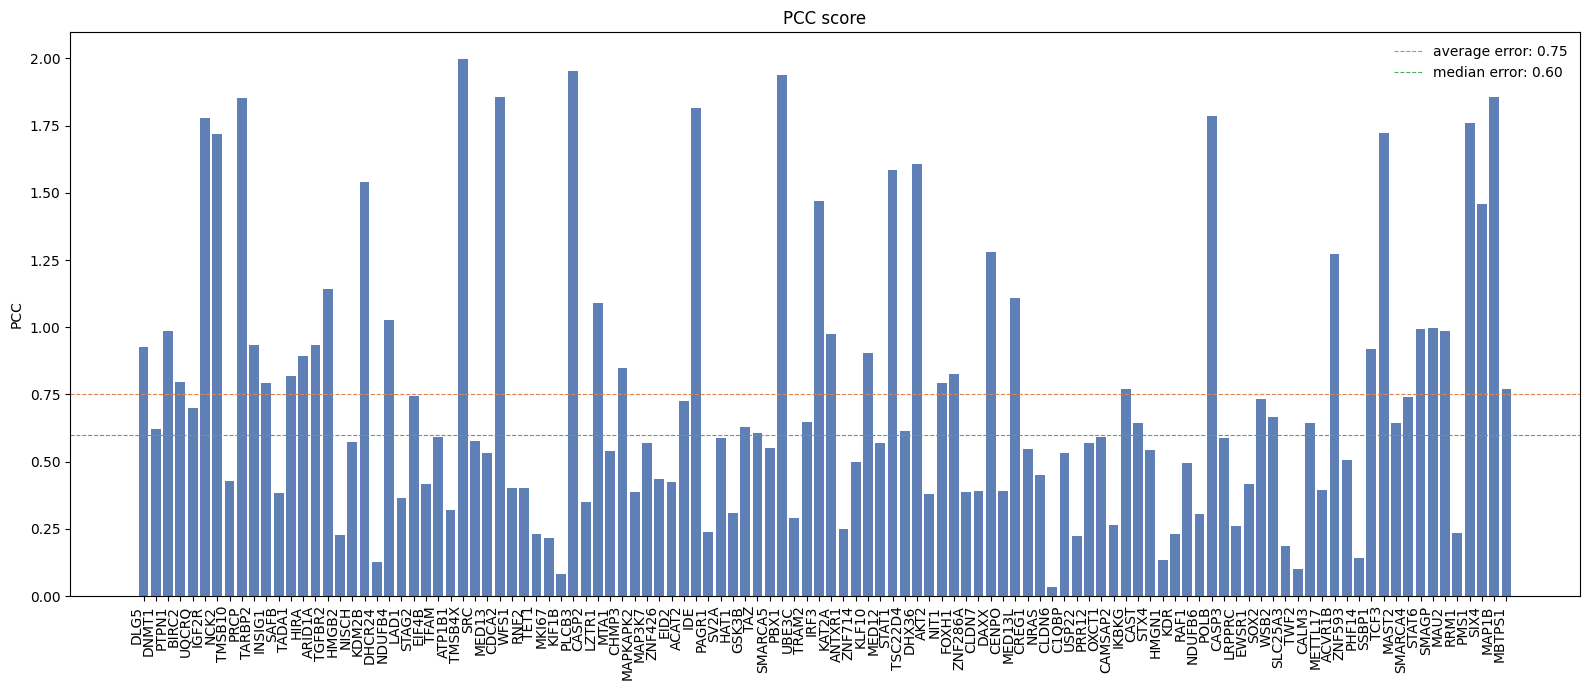

In [31]:
result_pcc = calc_pcc_delta(real_adata,pred_adata, n_top_degs=50)

# Extract keys and values
perts = list(result_pcc.keys())
values = list(result_pcc.values())

mean_score = sum(values) / len(values)
median_score = statistics.median(values)

plt.figure(figsize=(16, 7))
bars = plt.bar(perts, values, color='#4C72B0', alpha=0.9)
plt.xticks(rotation=90, ha='right')  # Vertical labels like your plot
plt.axhline(y=mean_score, color='#DD8452', linestyle='--', linewidth=0.8, label=f'average error: {mean_score:.2f}')
plt.axhline(y=median_score, color='#55A868', linestyle='--', linewidth=0.8, label=f'median error: {median_score:.2f}')
plt.ylabel('PCC')
plt.title('PCC score')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
result_edistance = calc_edistance(real_adata,pred_adata)

  0%|          | 0/112 [00:00<?, ?it/s]

  1%|          | 1/112 [00:02<04:20,  2.35s/it]

  2%|▏         | 2/112 [00:04<04:24,  2.40s/it]

  3%|▎         | 3/112 [00:07<04:22,  2.41s/it]

  4%|▎         | 4/112 [00:09<04:17,  2.39s/it]

...

 96%|█████████▋| 108/112 [04:23<00:09,  2.31s/it]

 97%|█████████▋| 109/112 [04:26<00:06,  2.29s/it]

 98%|█████████▊| 110/112 [04:28<00:04,  2.27s/it]

 99%|█████████▉| 111/112 [04:30<00:02,  2.28s/it]

100%|██████████| 112/112 [04:32<00:00,  2.44s/it]


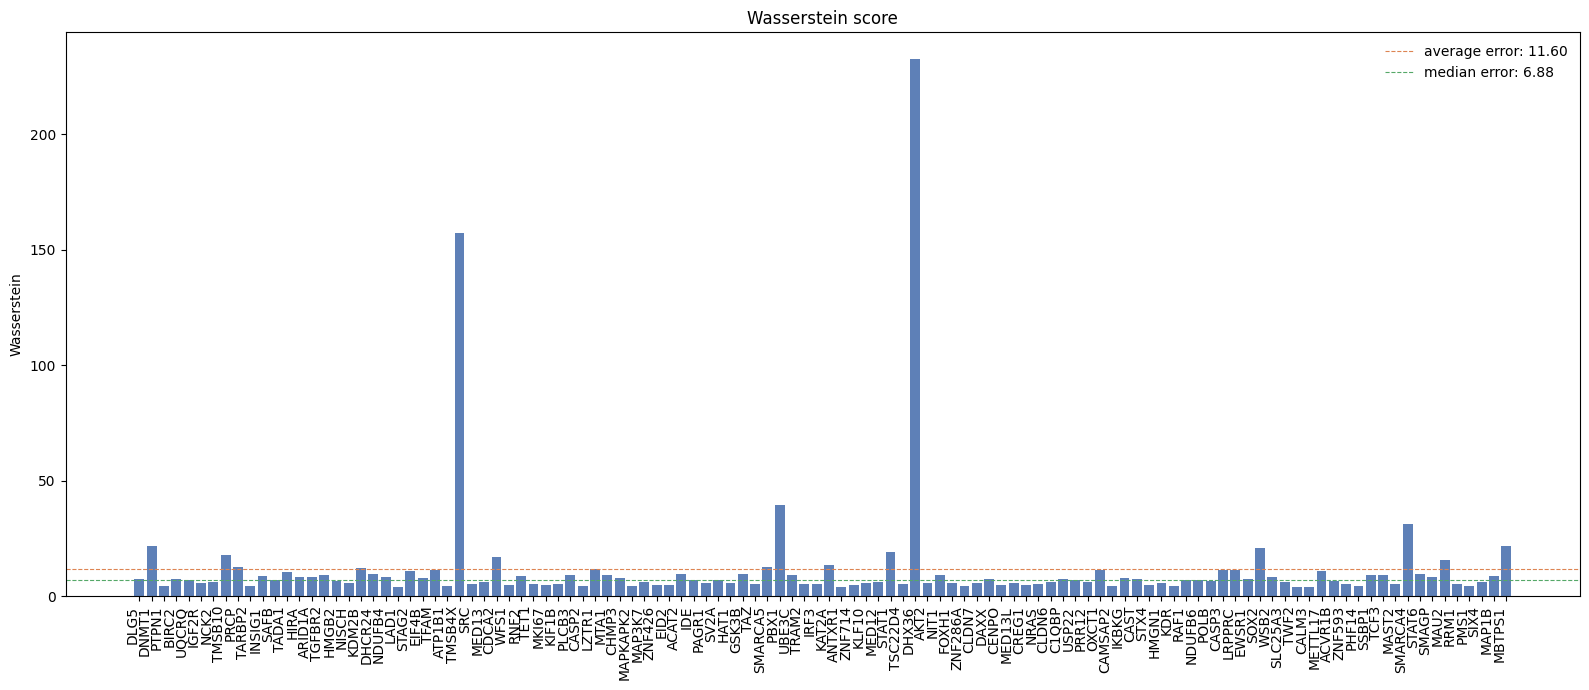

In [30]:
result_wasserstein = calc_wasserstein(real_adata,pred_adata, n_top_degs=50)

# Extract keys and values
perts = list(result_wasserstein.keys())
values = list(result_wasserstein.values())

mean_score = sum(values) / len(values)
median_score = statistics.median(values)

plt.figure(figsize=(16, 7))
bars = plt.bar(perts, values, color='#4C72B0', alpha=0.9)
plt.xticks(rotation=90, ha='right')  # Vertical labels like your plot
plt.axhline(y=mean_score, color='#DD8452', linestyle='--', linewidth=0.8, label=f'average error: {mean_score:.2f}')
plt.axhline(y=median_score, color='#55A868', linestyle='--', linewidth=0.8, label=f'median error: {median_score:.2f}')
plt.ylabel('Wasserstein')
plt.title('Wasserstein score')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
result_kl = calc_kldiv(real_adata,pred_adata)

100%|██████████| 112/112 [01:18<00:00,  1.42it/s]


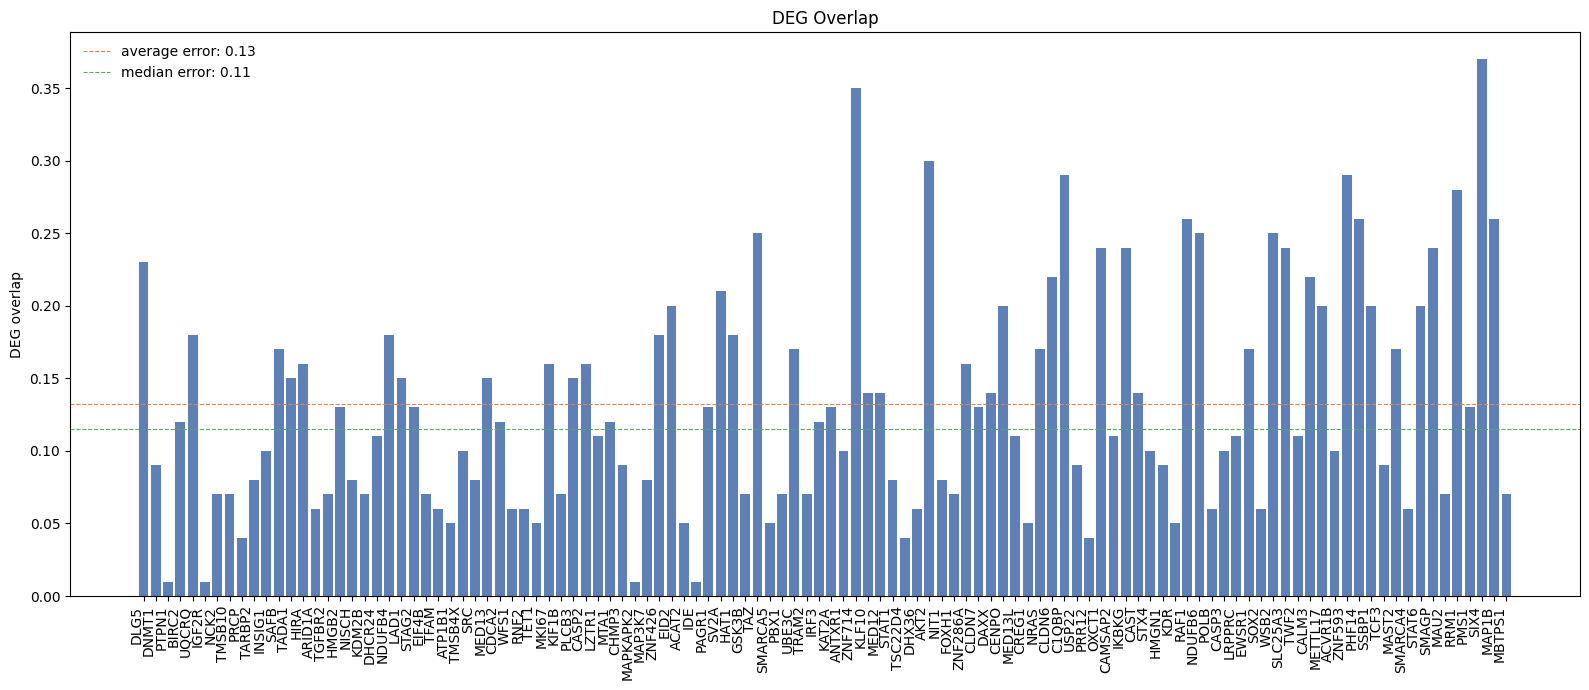

In [33]:
result_degs = calc_common_degs(real_adata,pred_adata)

# Extract keys and values
perts = list(result_degs.keys())
values = list(result_degs.values())

mean_score = sum(values) / len(values)
median_score = statistics.median(values)

plt.figure(figsize=(16, 7))
bars = plt.bar(perts, values, color='#4C72B0', alpha=0.9)
plt.xticks(rotation=90, ha='right')  # Vertical labels like your plot
plt.axhline(y=mean_score, color='#DD8452', linestyle='--', linewidth=0.8, label=f'average error: {mean_score:.2f}')
plt.axhline(y=median_score, color='#55A868', linestyle='--', linewidth=0.8, label=f'median error: {median_score:.2f}')
plt.ylabel('DEG overlap')
plt.title('DEG Overlap')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

100%|██████████| 112/112 [01:26<00:00,  1.29it/s]


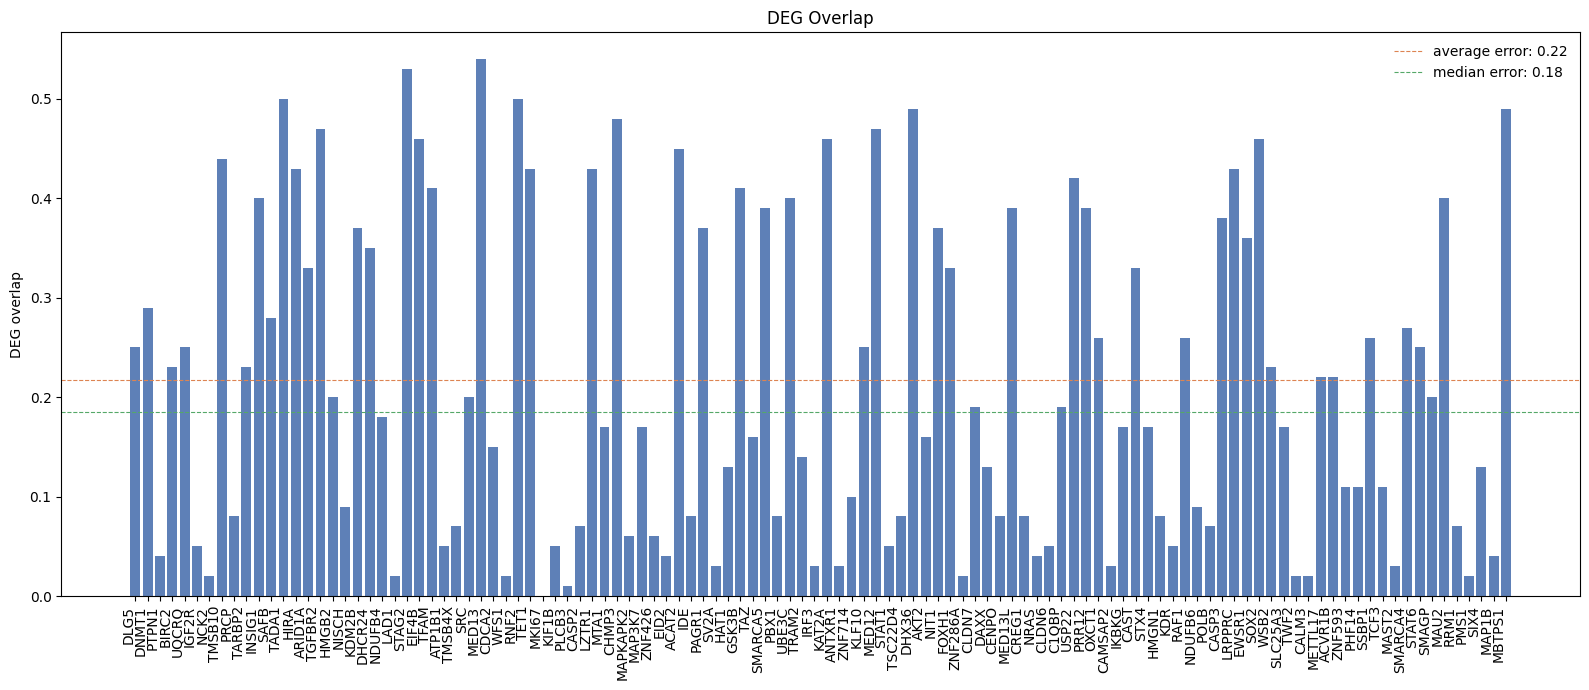

In [42]:
result_degs = calc_common_degs(real_adata,pred_adata_2)

# Extract keys and values
perts = list(result_degs.keys())
values = list(result_degs.values())

mean_score = sum(values) / len(values)
median_score = statistics.median(values)

plt.figure(figsize=(16, 7))
bars = plt.bar(perts, values, color='#4C72B0', alpha=0.9)
plt.xticks(rotation=90, ha='right')  # Vertical labels like your plot
plt.axhline(y=mean_score, color='#DD8452', linestyle='--', linewidth=0.8, label=f'average error: {mean_score:.2f}')
plt.axhline(y=median_score, color='#55A868', linestyle='--', linewidth=0.8, label=f'median error: {median_score:.2f}')
plt.ylabel('DEG overlap')
plt.title('DEG Overlap')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

***

### **Additional stuff**

In [ ]:
pred_adata.write('results/pred_adata.h5ad')
real_adata.write('results/real_adata.h5ad')

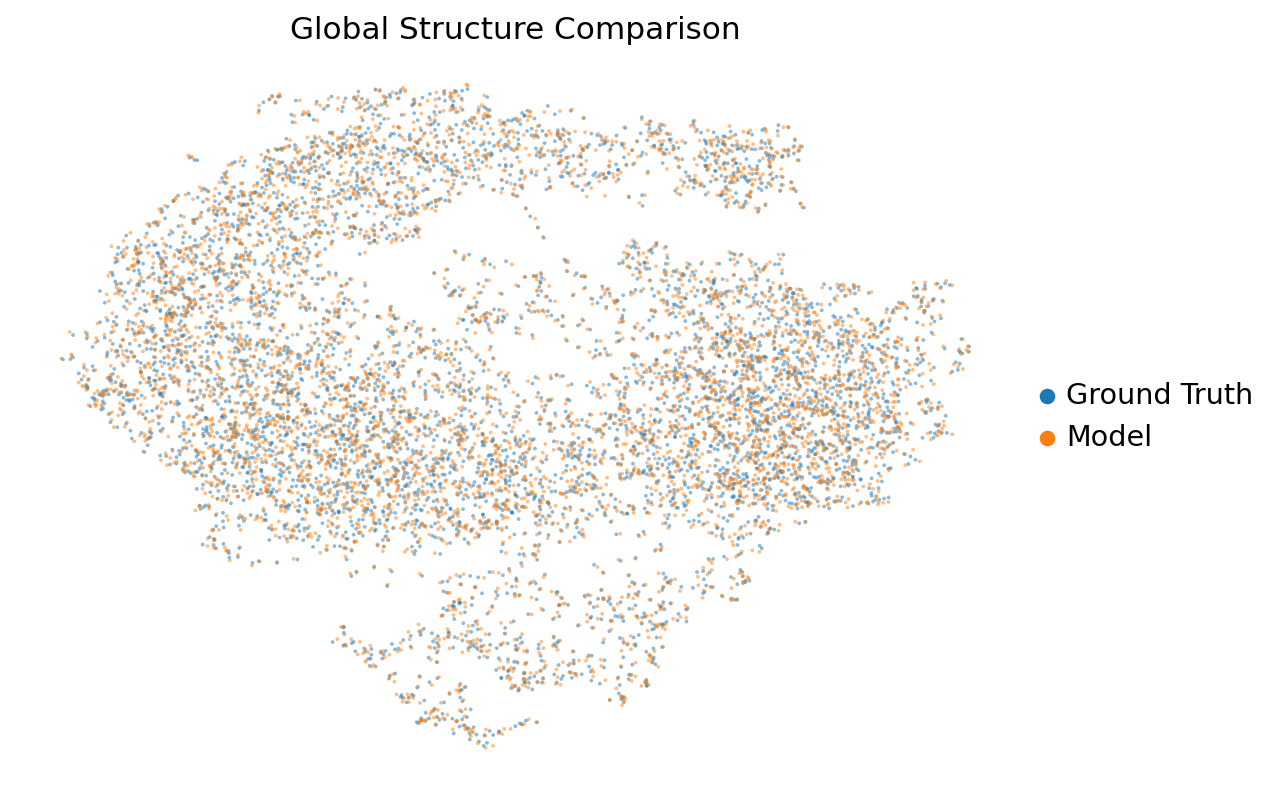

In [79]:
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Label your datasets
real_adata.obs['dataset'] = 'Ground Truth'
pred_adata.obs['dataset'] = 'Model'

# 2. Concatenate them
adata_combined = real_adata[real_adata.obs['target_gene']=='non-targeting'].concatenate(
    pred_adata[pred_adata.obs['target_gene']=='non-targeting'],
    batch_key='source',
    index_unique='-'
)

# 3. Compute embeddings
sc.pp.pca(adata_combined)
sc.pp.neighbors(adata_combined)
sc.tl.umap(adata_combined)   # <-- FIXED

# 4. Plot
sc.set_figure_params(figsize=(8, 6))
sc.pl.umap(
    adata_combined,
    color=['dataset'],
    alpha=0.5,
    title="Global Structure Comparison",
    frameon = False,
    #save = "umap.pdf"
)


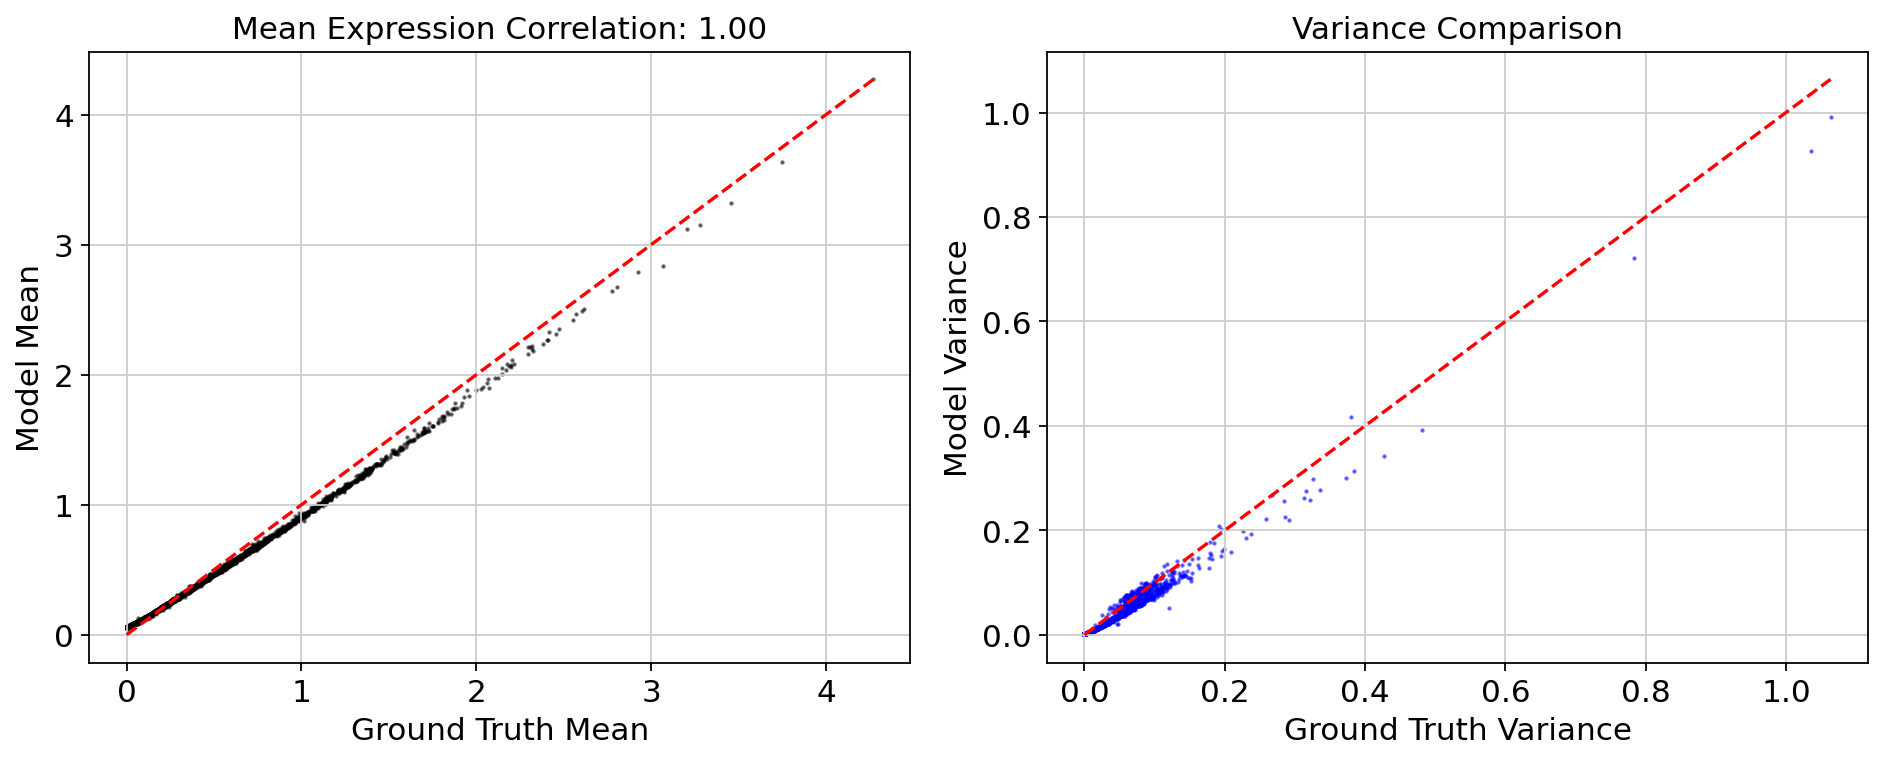

In [ ]:
import numpy as np
import seaborn as sns

# Helper function to get mean expression per gene
def get_gene_metrics(adata):
    # Handle sparse matrices if necessary
    if hasattr(adata.X, "toarray"):
        X = adata.X.toarray()
    else:
        X = adata.X
    
    mean_exp = np.mean(X, axis=0)
    var_exp = np.var(X, axis=0)
    return mean_exp, var_exp

gt_mean, gt_var = get_gene_metrics(real_adata)
model_mean, model_var = get_gene_metrics(pred_adata)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Mean Expression
ax[0].scatter(gt_mean, model_mean, s=1, alpha=0.5, c='k')
ax[0].plot([0, max(gt_mean)], [0, max(gt_mean)], 'r--') # Diagonal
ax[0].set_xlabel("Ground Truth Mean")
ax[0].set_ylabel("Model Mean")
ax[0].set_title(f"Mean Expression Correlation: {np.corrcoef(gt_mean, model_mean)[0,1]:.2f}")

# Plot 2: Variance (Dispersion)
ax[1].scatter(gt_var, model_var, s=1, alpha=0.5, c='b')
ax[1].plot([0, max(gt_var)], [0, max(gt_var)], 'r--') # Diagonal
ax[1].set_xlabel("Ground Truth Variance")
ax[1].set_ylabel("Model Variance")
ax[1].set_title("Variance Comparison")

plt.tight_layout()
plt.show()

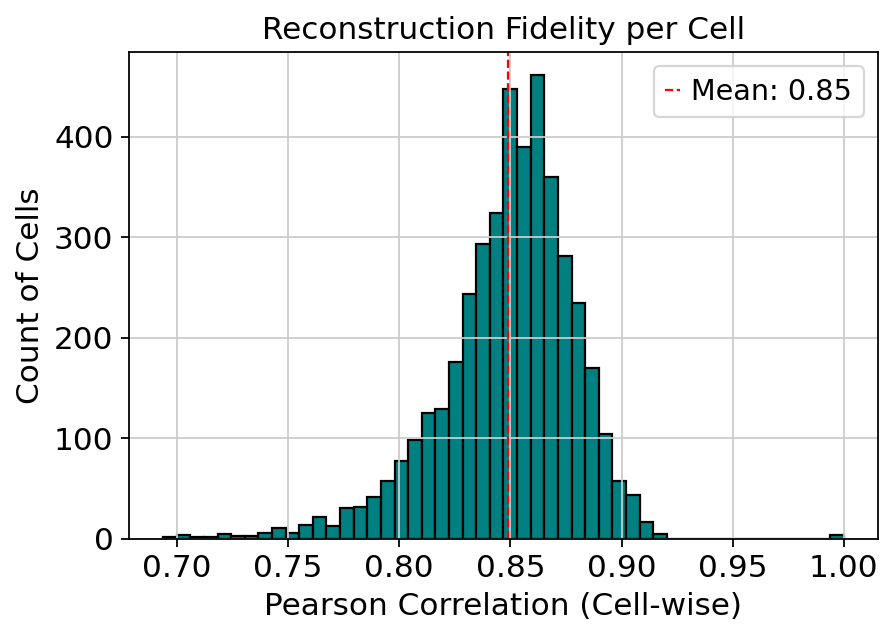

In [ ]:
from scipy.stats import pearsonr

correlations = []
n_cells = pred_adata.shape[0]

# Convert to dense once if memory allows, or iterate carefully
X_gt = real_adata.X if not hasattr(real_adata.X, "toarray") else real_adata.X.toarray()
X_model = pred_adata.X if not hasattr(pred_adata.X, "toarray") else pred_adata.X.toarray()

for i in range(n_cells):
    # Calculate correlation for cell i
    corr, _ = pearsonr(X_gt[i], X_model[i])
    correlations.append(corr)

# Plot Histogram of Correlations
plt.figure(figsize=(6, 4))
plt.hist(correlations, bins=50, color='teal', edgecolor='black')
plt.xlabel("Pearson Correlation (Cell-wise)")
plt.ylabel("Count of Cells")
plt.title("Reconstruction Fidelity per Cell")
plt.axvline(np.mean(correlations), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(correlations):.2f}')
plt.legend()
plt.show()

***

### **Generative model - please work**

In [ ]:
def generate_adata(perts_x_ncells, model, gene_to_idx, var_names):
    prediction_list = []
    obs_gene_list = []

    # for each perturbation....
    for pert in perts_x_ncells.keys():
        if pert != "non-targeting":
            print(pert)

            # how many cells are in the real data and I have to generate with the generative model?
            n_cells = perts_x_ncells[pert]

            # index corresponding to the pert
            ko_gene_idx = gene_to_idx[pert]

            # generate n_cell perturbed cells
            for j in range(n_cells):
                _, predicted_full_gex = model.generative_prediction(ko_gene_idx)
                predicted_full_gex = predicted_full_gex.reshape(1,-1).detach().cpu()
                prediction_list.append(predicted_full_gex.numpy()) 
                obs_gene_list.append(pert)

    # Stack all (1, N) vectors → shape (total_cells, N)
    X = np.vstack(prediction_list)

    # Build obs dataframe
    obs = pd.DataFrame({
        "target_gene": obs_gene_list
    })

    # Build var dataframe (gene names)
    var = pd.DataFrame(index=var_names)   # length N list of gene names

    pred_adata = ad.AnnData(X=X, obs=obs, var=var)
    return pred_adata

In [ ]:
counts = real_adata.obs['target_gene'].value_counts()
counts = counts[counts >= 200]

# Remove 'non-targeting'
gene_counts_dict = counts.drop('non-targeting').to_dict()
del counts

pred_adata2 = generate_adata(gene_counts_dict, model, gene_to_idx, real_adata.var_names)
pred_adata2


***

### Other analysis

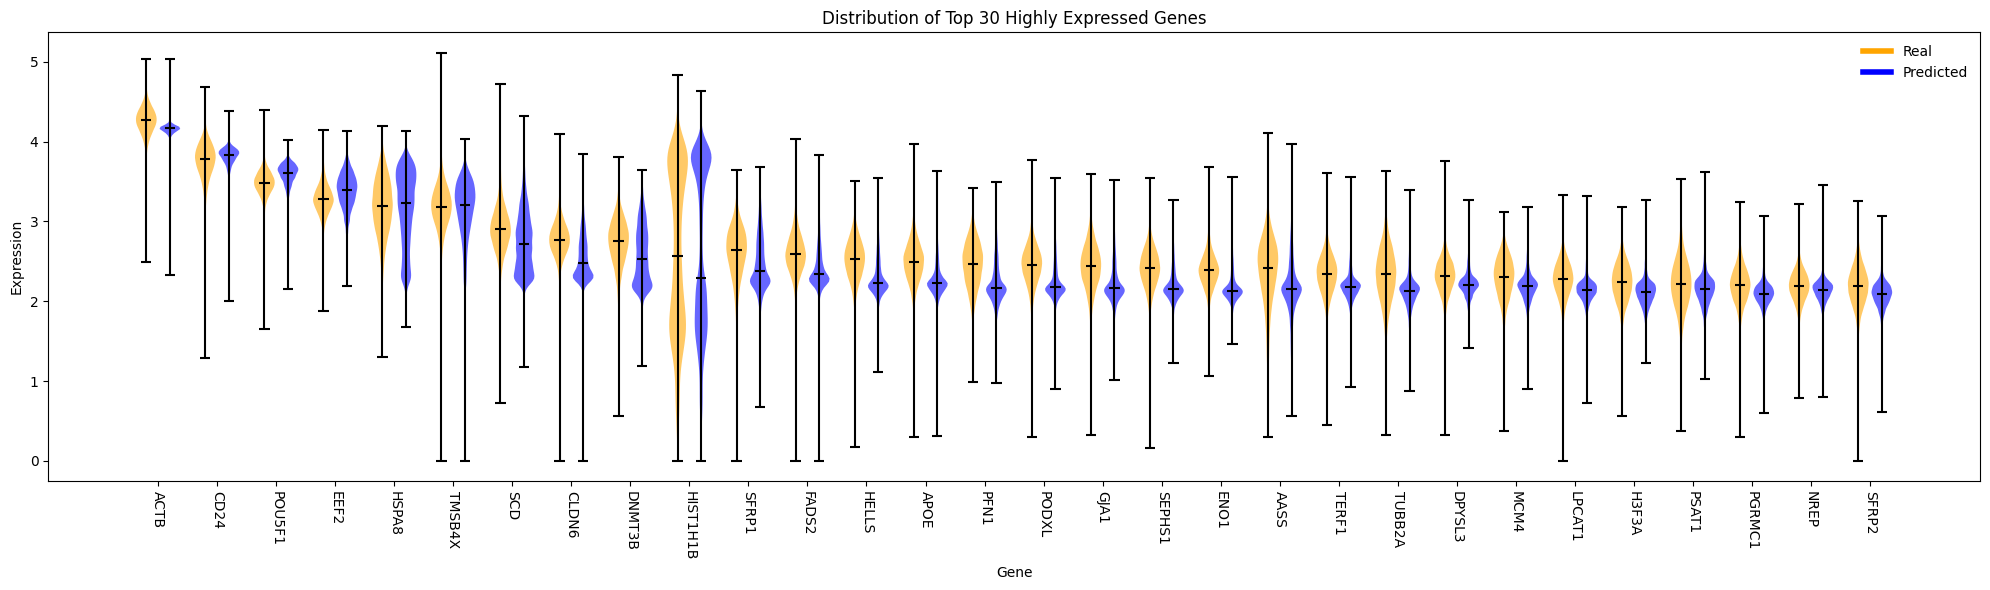

In [38]:
from visualization import plot_top_highly_expressed_genes
from visualization import plot_top_highly_variable_genes

plot_top_highly_expressed_genes(30, real_adata, pred_adata, False)

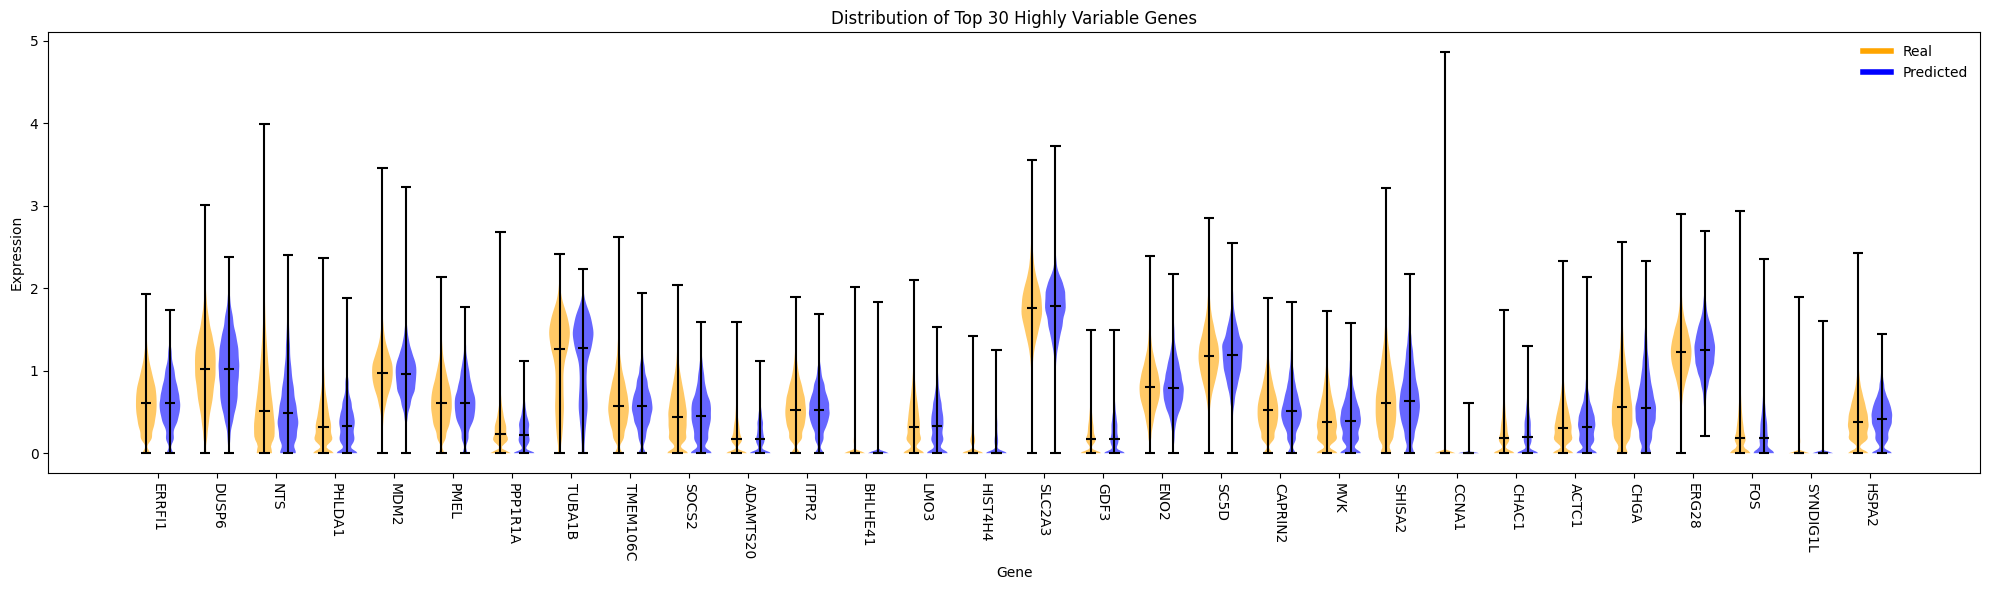

In [39]:
plot_top_highly_variable_genes(30, real_adata, pred_adata, False)

**let's try with just the DE genes**

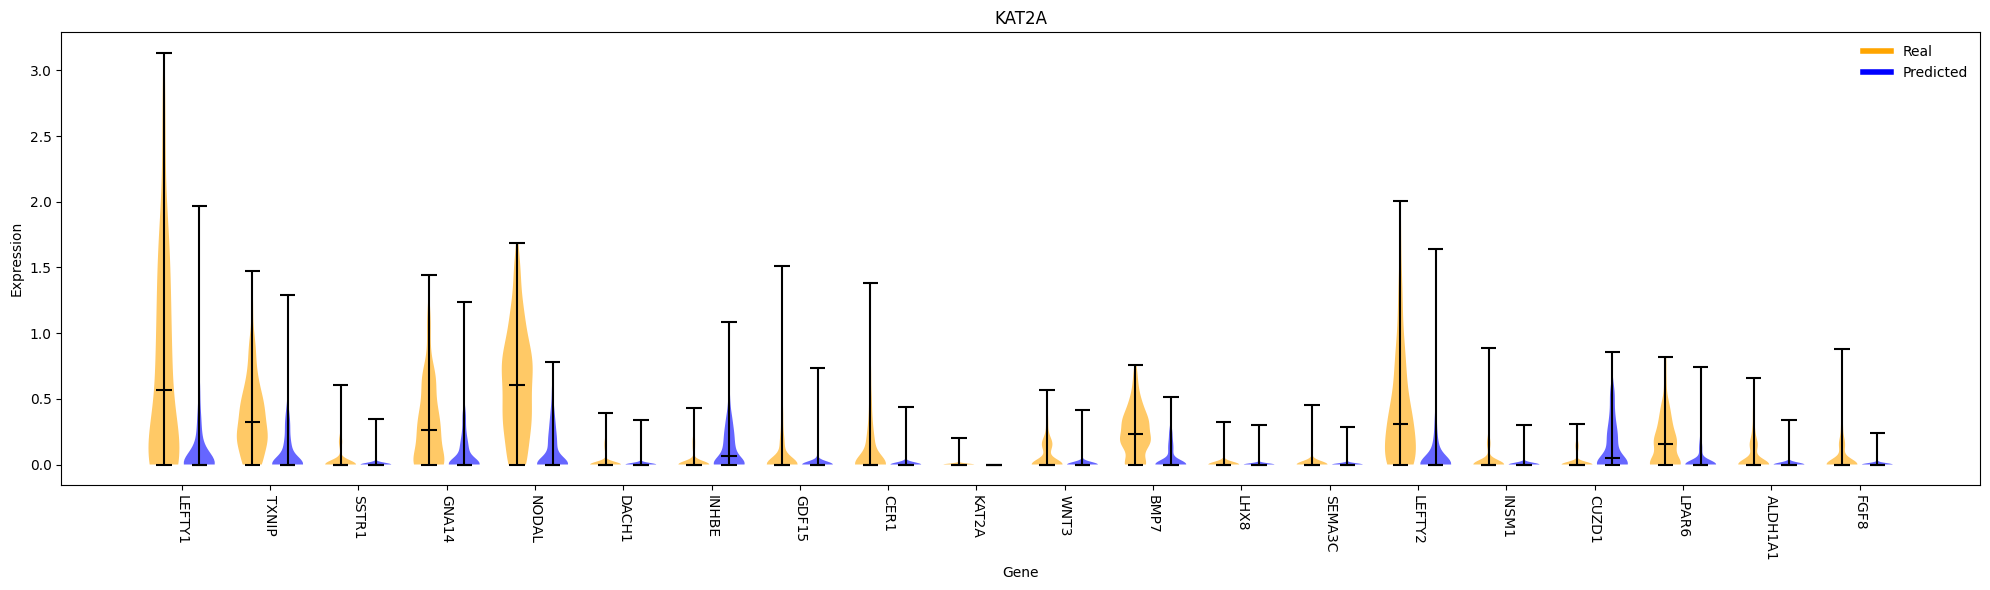

In [40]:
from scores import RobustDES
from visualization import plot_violins_redictions_selected_genes


des_calculator = RobustDES(lfc_threshold=0.5, alpha=0.05)

max_de_genes = 20
perturb_label = 'KAT2A'
DE_genes, _ = des_calculator.get_de_genes(real_adata, 'target_gene', perturb_label, 'non-targeting')
list_DE_genes = list(set(DE_genes.index))
if len(list_DE_genes)>max_de_genes:
    list_DE_genes = list(set(DE_genes.loc[DE_genes['logfoldchanges'].abs().sort_values(ascending=False).index[:max_de_genes]].index))

plot_violins_redictions_selected_genes(list_DE_genes, 
    real_adata[real_adata.obs['target_gene']==perturb_label], 
    pred_adata[pred_adata.obs['target_gene']==perturb_label], 
    False, 
    perturb_label
)


In [43]:
import seaborn as sns
from scipy.stats import wasserstein_distance, pearsonr
from sklearn.metrics import r2_score

In [44]:
def plot_lfc_correlation(real_adata, pred_adata, perturb_list, des_calculator, 
                         target_col='target_gene', ctrl_label='non-targeting', save=False):
    """
    Plots a scatter plot of Real vs Predicted Log2 Fold Changes for DE genes across multiple perturbations.
    """
    all_real_lfcs = []
    all_pred_lfcs = []
    
    # Get the real control cells to serve as the baseline for predicted LFC
    real_ctrl_adata = real_adata[real_adata.obs[target_col] == ctrl_label]
    
    for perturb in perturb_list:
        # 1. Get Real DE genes and their Real LFCs
        de_df, _ = des_calculator.get_de_genes(real_adata, target_col, perturb, ctrl_label)
        if de_df.empty:
            continue
            
        de_genes = de_df.index.tolist()
        real_lfc = de_df['logfoldchanges'].values
        
        # 2. Calculate Predicted LFCs for these specific DE genes
        pred_perturb_adata = pred_adata[pred_adata.obs[target_col] == perturb]
        
        # Extract matrices
        pred_X = pred_perturb_adata[:, de_genes].X
        ctrl_X = real_ctrl_adata[:, de_genes].X
        
        if hasattr(pred_X, "toarray"): pred_X = pred_X.toarray()
        if hasattr(ctrl_X, "toarray"): ctrl_X = ctrl_X.toarray()
            
        # Means per gene (add small pseudocount to avoid log(0))
        mean_pred = pred_X.mean(axis=0) + 1e-9
        mean_ctrl = ctrl_X.mean(axis=0) + 1e-9
        
        # Log2 fold change: log2(Predicted Perturb / Real Control)
        pred_lfc = np.log2(mean_pred / mean_ctrl)
        
        all_real_lfcs.extend(real_lfc)
        all_pred_lfcs.extend(pred_lfc)
        
    # Calculate global Pearson correlation
    r_val, p_val = pearsonr(all_real_lfcs, all_pred_lfcs)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(8, 8))
    sns.scatterplot(x=all_real_lfcs, y=all_pred_lfcs, alpha=0.5, s=10, edgecolor=None, color='#1f77b4', ax=ax)
    
    # Plot identity line (y = x)
    min_val = min(min(all_real_lfcs), min(all_pred_lfcs))
    max_val = max(max(all_real_lfcs), max(all_pred_lfcs))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=0.5, label='Perfect Prediction (y=x)')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_xlabel('Ground Truth LFC (Real Perturbed vs Real Control)')
    ax.set_ylabel('Predicted LFC (Pred Perturbed vs Real Control)')
    ax.set_title(f'Global LFC Correlation\nPearson R = {r_val:.3f} (p={p_val:.2e})')
    ax.legend(frameon=False)
    
    sns.despine()
    plt.tight_layout()
    
    if save:
        fig.savefig('LFC_Correlation_Plot.pdf')
    plt.show()

In [45]:
def plot_wasserstein_distances(real_adata, pred_adata, perturb_list, des_calculator, 
                               target_col='target_gene', ctrl_label='non-targeting', save=False):
    """
    Calculates the average Wasserstein distance of DE genes between real and predicted cells for each perturbation.
    """
    perturb_distances = {}
    
    for perturb in perturb_list:
        de_df, _ = des_calculator.get_de_genes(real_adata, target_col, perturb, ctrl_label)
        if de_df.empty:
            continue
            
        de_genes = de_df.index.tolist()
        
        # Isolate the cells for this specific perturbation
        real_vals = real_adata[real_adata.obs[target_col] == perturb, de_genes].X
        pred_vals = pred_adata[pred_adata.obs[target_col] == perturb, de_genes].X
        
        if hasattr(real_vals, "toarray"): real_vals = real_vals.toarray()
        if hasattr(pred_vals, "toarray"): pred_vals = pred_vals.toarray()
            
        # Calculate Wasserstein distance for each gene independently
        w_dists = [wasserstein_distance(real_vals[:, i], pred_vals[:, i]) for i in range(len(de_genes))]
        
        # Store the average distance for this perturbation
        perturb_distances[perturb] = np.mean(w_dists)
        
    # Convert to DataFrame for easy Seaborn plotting and sorting
    df_dists = pd.DataFrame(list(perturb_distances.items()), columns=['Perturbation', 'Avg_Wasserstein_Distance'])
    df_dists = df_dists.sort_values('Avg_Wasserstein_Distance', ascending=False) # Highest distance = worst prediction
    
    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=df_dists, x='Perturbation', y='Avg_Wasserstein_Distance', color='salmon', ax=ax)
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_ylabel('Average Wasserstein Distance (Lower is better)')
    ax.set_xlabel('Perturbations')
    ax.set_title('Distribution Match between Real and Predicted Perturbations')
    
    sns.despine()
    plt.tight_layout()
    
    if save:
        fig.savefig('Wasserstein_Distances.pdf')
    plt.show()

In [46]:
def plot_delta_mean_r2(real_adata, pred_adata, perturb_list, des_calculator, 
                       target_col='target_gene', ctrl_label='non-targeting', save=False):
    """
    Calculates the R-squared score between the real and predicted *change in mean expression* (Delta) of DE genes relative to the control state.
    """
    perturb_r2 = {}
    
    # Baseline: Real control cells
    real_ctrl_adata = real_adata[real_adata.obs[target_col] == ctrl_label]
    
    for perturb in perturb_list:
        de_df, _ = des_calculator.get_de_genes(real_adata, target_col, perturb, ctrl_label)
        
        # R2 score requires at least 2 genes to compute variance.
        if de_df.empty or len(de_df) < 2:
            continue
            
        de_genes = de_df.index.tolist()
        
        # Isolate matrices
        real_perturb_X = real_adata[real_adata.obs[target_col] == perturb, de_genes].X
        pred_perturb_X = pred_adata[pred_adata.obs[target_col] == perturb, de_genes].X
        real_ctrl_X = real_ctrl_adata[:, de_genes].X
        
        if hasattr(real_perturb_X, "toarray"): real_perturb_X = real_perturb_X.toarray()
        if hasattr(pred_perturb_X, "toarray"): pred_perturb_X = pred_perturb_X.toarray()
        if hasattr(real_ctrl_X, "toarray"): real_ctrl_X = real_ctrl_X.toarray()
        
        # Calculate means
        real_perturb_means = real_perturb_X.mean(axis=0)
        pred_perturb_means = pred_perturb_X.mean(axis=0)
        real_ctrl_means = real_ctrl_X.mean(axis=0)
        
        # CALCULATE DELTAS (Effect Size)
        real_delta = real_perturb_means - real_ctrl_means
        pred_delta = pred_perturb_means - real_ctrl_means
        
        # Calculate R-squared score on the deltas
        r2 = r2_score(real_delta, pred_delta)
        perturb_r2[perturb] = r2
        
    # Convert to DataFrame
    df_r2 = pd.DataFrame(list(perturb_r2.items()), columns=['Perturbation', 'R2_Score_of_Delta'])
    df_r2 = df_r2.sort_values('R2_Score_of_Delta', ascending=False)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=df_r2, x='Perturbation', y='R2_Score_of_Delta', color='mediumseagreen', ax=ax)
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_ylabel('$R^2$ Score of Delta (Higher is better)')
    ax.set_xlabel('Perturbations')
    ax.set_title('$R^2$ of Perturbation Effect (Delta) per Perturbation')
    ax.axhline(0, color='black', lw=1) # Baseline at 0 (worse than 0 means predicting the mean delta is better)
    
    sns.despine()
    plt.tight_layout()
    
    if save:
        fig.savefig('Delta_R2_Scores.pdf')
    plt.show()

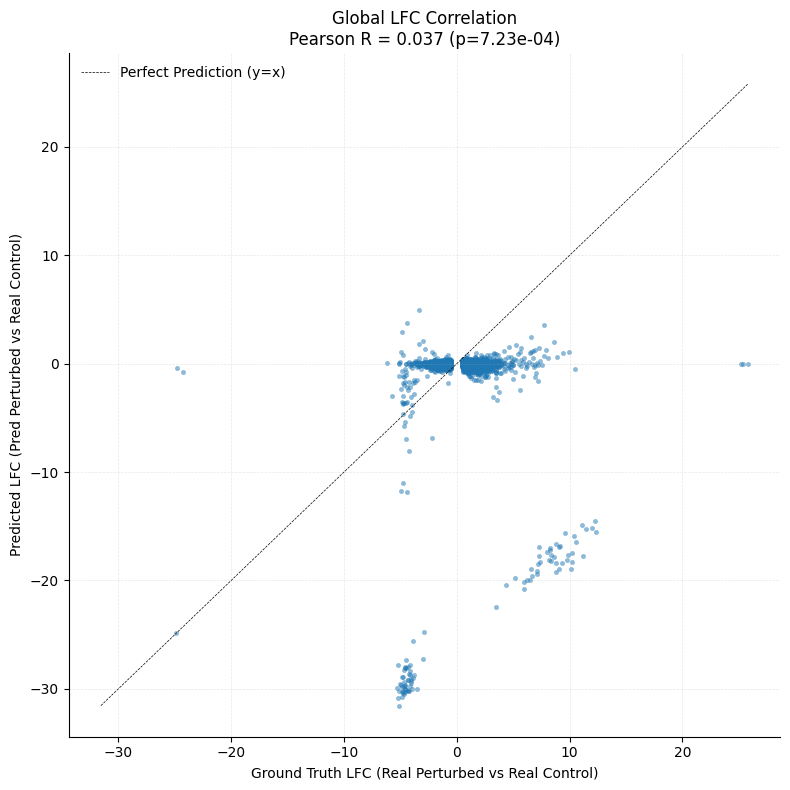

In [47]:
# Remove the control label from your perturbation list so we don't calculate DE for control vs control
perturb_list = [p for p in real_adata.obs['target_gene'].unique() if p != 'non-targeting']

# Option A: Plot Global LFC Scatter
plot_lfc_correlation(real_adata, pred_adata, perturb_list, des_calculator, save=False)


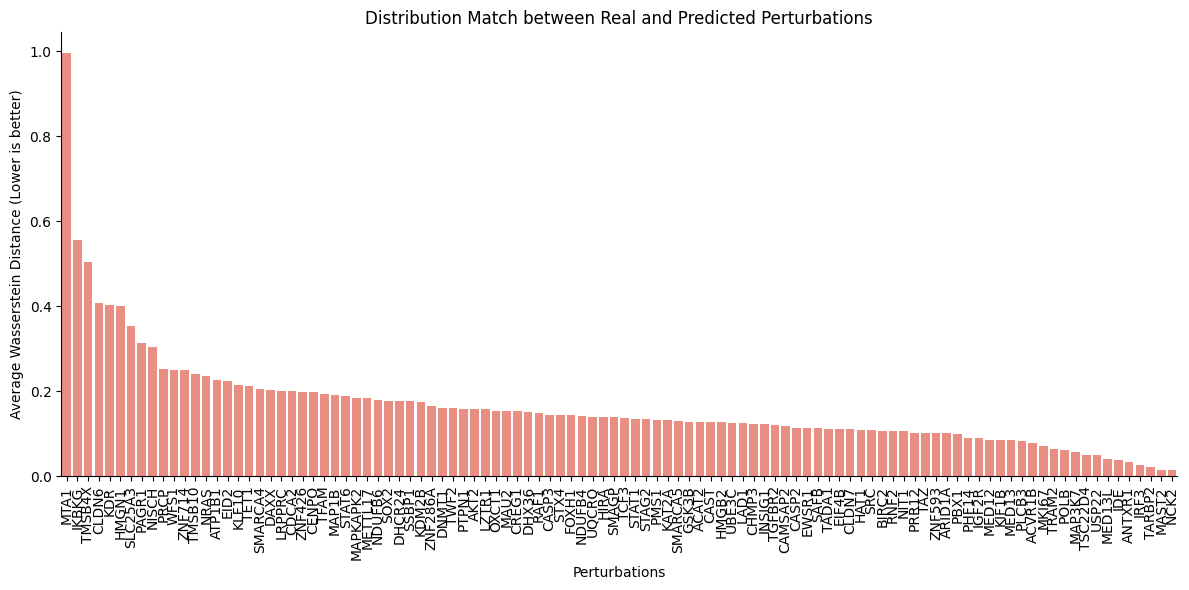

In [48]:

# Option B: Plot Wasserstein Distance Bar Chart
plot_wasserstein_distances(real_adata, pred_adata, perturb_list, des_calculator, save=False)


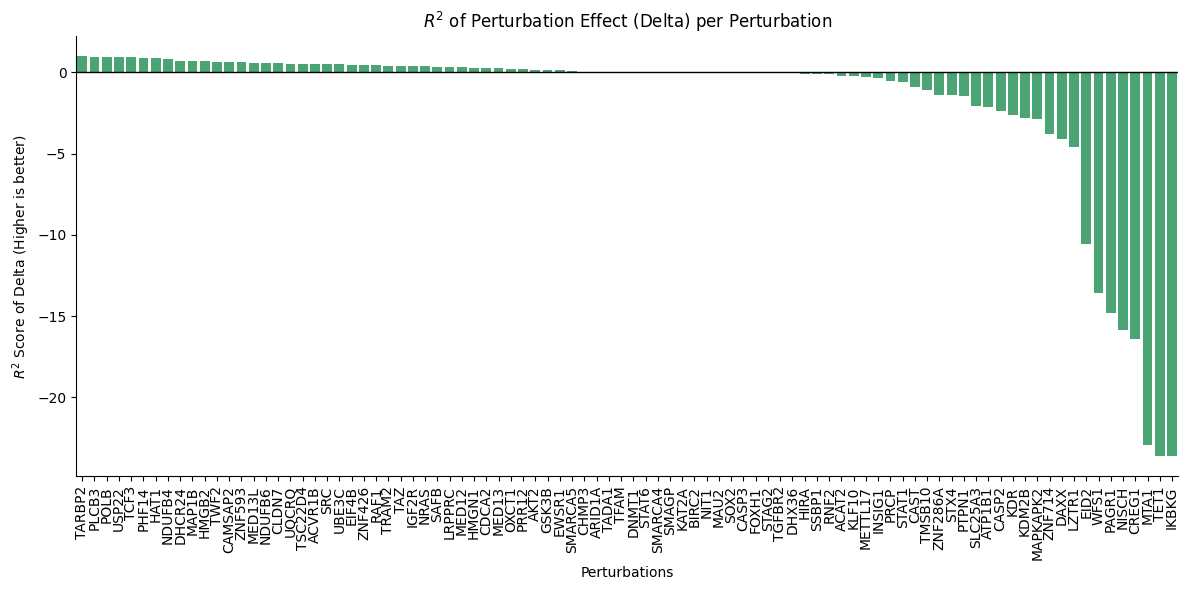

In [49]:
# Option C: Plot R2 Bar Chart
plot_delta_mean_r2(real_adata, pred_adata, perturb_list, des_calculator, save=False)